In [1]:
import pandas as pd
import numpy as np
import datetime
from time import strftime
import matplotlib.pyplot as plt
%matplotlib inline

import seaborn as sns

In [4]:
base_data = pd.read_csv('Data.csv')

In [5]:
base_data

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
0,2.987250e+13,5642903,F,2016-04-29T18:38:08Z,2016-04-29T00:00:00Z,62,JARDIM DA PENHA,0,1,0,0,0,0,No
1,5.589978e+14,5642503,M,2016-04-29T16:08:27Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,0,0,0,0,0,No
2,4.262962e+12,5642549,F,2016-04-29T16:19:04Z,2016-04-29T00:00:00Z,62,MATA DA PRAIA,0,0,0,0,0,0,No
3,8.679512e+11,5642828,F,2016-04-29T17:29:31Z,2016-04-29T00:00:00Z,8,PONTAL DE CAMBURI,0,0,0,0,0,0,No
4,8.841186e+12,5642494,F,2016-04-29T16:07:23Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,1,1,0,0,0,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
110522,2.572134e+12,5651768,F,2016-05-03T09:15:35Z,2016-06-07T00:00:00Z,56,MARIA ORTIZ,0,0,0,0,0,1,No
110523,3.596266e+12,5650093,F,2016-05-03T07:27:33Z,2016-06-07T00:00:00Z,51,MARIA ORTIZ,0,0,0,0,0,1,No
110524,1.557663e+13,5630692,F,2016-04-27T16:03:52Z,2016-06-07T00:00:00Z,21,MARIA ORTIZ,0,0,0,0,0,1,No
110525,9.213493e+13,5630323,F,2016-04-27T15:09:23Z,2016-06-07T00:00:00Z,38,MARIA ORTIZ,0,0,0,0,0,1,No


In [6]:
base_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110527 entries, 0 to 110526
Data columns (total 14 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   PatientId       110527 non-null  float64
 1   AppointmentID   110527 non-null  int64  
 2   Gender          110527 non-null  object 
 3   ScheduledDay    110527 non-null  object 
 4   AppointmentDay  110527 non-null  object 
 5   Age             110527 non-null  int64  
 6   Neighbourhood   110527 non-null  object 
 7   Scholarship     110527 non-null  int64  
 8   Hipertension    110527 non-null  int64  
 9   Diabetes        110527 non-null  int64  
 10  Alcoholism      110527 non-null  int64  
 11  Handcap         110527 non-null  int64  
 12  SMS_received    110527 non-null  int64  
 13  No-show         110527 non-null  object 
dtypes: float64(1), int64(8), object(5)
memory usage: 11.8+ MB


In [7]:
#modifying the date and time into standard form
base_data['ScheduledDay'] = pd.to_datetime(base_data['ScheduledDay']).dt.date.astype('datetime64[ns]')
base_data['AppointmentDay'] = pd.to_datetime(base_data['AppointmentDay']).dt.date.astype('datetime64[ns]')

In [8]:
base_data.head(5)

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
0,2.987250e+13,5642903,F,2016-04-29,2016-04-29,62,JARDIM DA PENHA,0,1,0,0,0,0,No
1,5.589978e+14,5642503,M,2016-04-29,2016-04-29,56,JARDIM DA PENHA,0,0,0,0,0,0,No
2,4.262962e+12,5642549,F,2016-04-29,2016-04-29,62,MATA DA PRAIA,0,0,0,0,0,0,No
3,8.679512e+11,5642828,F,2016-04-29,2016-04-29,8,PONTAL DE CAMBURI,0,0,0,0,0,0,No
4,8.841186e+12,5642494,F,2016-04-29,2016-04-29,56,JARDIM DA PENHA,0,1,1,0,0,0,No


In [9]:
base_data.columns

Index(['PatientId', 'AppointmentID', 'Gender', 'ScheduledDay',
       'AppointmentDay', 'Age', 'Neighbourhood', 'Scholarship', 'Hipertension',
       'Diabetes', 'Alcoholism', 'Handcap', 'SMS_received', 'No-show'],
      dtype='object')

In [10]:
# dropping some columns which have no significance
base_data.drop(['PatientId', 'AppointmentID', 'Neighbourhood'], axis=1, inplace=True)

In [11]:
base_data.columns

Index(['Gender', 'ScheduledDay', 'AppointmentDay', 'Age', 'Scholarship',
       'Hipertension', 'Diabetes', 'Alcoholism', 'Handcap', 'SMS_received',
       'No-show'],
      dtype='object')

In [12]:
#changing the name of some cloumns
base_data= base_data.rename(columns={'Hipertension': 'Hypertension', 'Handcap': 'Handicap', 'SMS_received': 'SMSReceived', 'No-show': 'NoShow'})

In [13]:
base_data.columns

Index(['Gender', 'ScheduledDay', 'AppointmentDay', 'Age', 'Scholarship',
       'Hypertension', 'Diabetes', 'Alcoholism', 'Handicap', 'SMSReceived',
       'NoShow'],
      dtype='object')

In [14]:
base_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110527 entries, 0 to 110526
Data columns (total 11 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   Gender          110527 non-null  object        
 1   ScheduledDay    110527 non-null  datetime64[ns]
 2   AppointmentDay  110527 non-null  datetime64[ns]
 3   Age             110527 non-null  int64         
 4   Scholarship     110527 non-null  int64         
 5   Hypertension    110527 non-null  int64         
 6   Diabetes        110527 non-null  int64         
 7   Alcoholism      110527 non-null  int64         
 8   Handicap        110527 non-null  int64         
 9   SMSReceived     110527 non-null  int64         
 10  NoShow          110527 non-null  object        
dtypes: datetime64[ns](2), int64(7), object(2)
memory usage: 9.3+ MB


In [15]:
base_data.describe()

,ScheduledDay,AppointmentDay,Age,Scholarship,Hypertension,Diabetes,Alcoholism,Handicap,SMSReceived
count,110527,110527,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000
mean,2016-05-08 20:33:18.179630080,2016-05-19 00:57:50.008233472,37.088874,0.098266,0.197246,0.071865,0.030400,0.022248,0.321026
min,2015-11-10 00:00:00,2016-04-29 00:00:00,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2016-04-29 00:00:00,2016-05-09 00:00:00,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,2016-05-10 00:00:00,2016-05-18 00:00:00,37.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,2016-05-20 00:00:00,2016-05-31 00:00:00,55.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
max,2016-06-08 00:00:00,2016-06-08 00:00:00,115.000000,1.000000,1.000000,1.000000,1.000000,4.000000,1.000000
std,NaN,NaN,23.110205,0.297675,0.397921,0.258265,0.171686,0.161543,0.466873


In [17]:
print(f"\nNegative age rows : {(base_data['Age'] < 0).sum()}")
base_data= base_data[base_data["Age"] >= 0].copy() 


Negative age rows : 1


In [30]:
base_data["AppDayOfWeek"] = base_data["AppointmentDay"].dt.day_name()
base_data["AppMonth"]     = base_data["AppointmentDay"].dt.month

In [31]:
base_data.head()


,Gender,ScheduledDay,AppointmentDay,Age,Scholarship,Hypertension,Diabetes,Alcoholism,Handicap,SMSReceived,NoShow,AppDayOfWeek,AppMonth,WaitDays,App_Day_Of_Week,App_Month
0,F,2016-04-29,2016-04-29,62,0,1,0,0,0,0,No,Friday,4,0,Friday,4
1,M,2016-04-29,2016-04-29,56,0,0,0,0,0,0,No,Friday,4,0,Friday,4
2,F,2016-04-29,2016-04-29,62,0,0,0,0,0,0,No,Friday,4,0,Friday,4
3,F,2016-04-29,2016-04-29,8,0,0,0,0,0,0,No,Friday,4,0,Friday,4
4,F,2016-04-29,2016-04-29,56,0,1,1,0,0,0,No,Friday,4,0,Friday,4


In [32]:
# Drop the underscore versions
base_data.drop(columns=["App_Day_Of_Week", "App_Month"], inplace=True)

base_data.head()

,Gender,ScheduledDay,AppointmentDay,Age,Scholarship,Hypertension,Diabetes,Alcoholism,Handicap,SMSReceived,NoShow,AppDayOfWeek,AppMonth,WaitDays
0,F,2016-04-29,2016-04-29,62,0,1,0,0,0,0,No,Friday,4,0
1,M,2016-04-29,2016-04-29,56,0,0,0,0,0,0,No,Friday,4,0
2,F,2016-04-29,2016-04-29,62,0,0,0,0,0,0,No,Friday,4,0
3,F,2016-04-29,2016-04-29,8,0,0,0,0,0,0,No,Friday,4,0
4,F,2016-04-29,2016-04-29,56,0,1,1,0,0,0,No,Friday,4,0


In [33]:
list(base_data.columns)

['Gender',
 'ScheduledDay',
 'AppointmentDay',
 'Age',
 'Scholarship',
 'Hypertension',
 'Diabetes',
 'Alcoholism',
 'Handicap',
 'SMSReceived',
 'NoShow',
 'AppDayOfWeek',
 'AppMonth',
 'WaitDays']

In [35]:
base_data["AgeBucket"] = pd.cut(base_data["Age"],
                          bins=[-1, 10, 20, 30, 40, 50, 60, 70, 80, 120],
                          labels=["0-10","11-20","21-30","31-40",
                                  "41-50","51-60","61-70","71-80","80+"])

In [36]:
base_data.head()

,Gender,ScheduledDay,AppointmentDay,Age,Scholarship,Hypertension,Diabetes,Alcoholism,Handicap,SMSReceived,NoShow,AppDayOfWeek,AppMonth,WaitDays,AgeBucket
0,F,2016-04-29,2016-04-29,62,0,1,0,0,0,0,No,Friday,4,0,61-70
1,M,2016-04-29,2016-04-29,56,0,0,0,0,0,0,No,Friday,4,0,51-60
2,F,2016-04-29,2016-04-29,62,0,0,0,0,0,0,No,Friday,4,0,61-70
3,F,2016-04-29,2016-04-29,8,0,0,0,0,0,0,No,Friday,4,0,0-10
4,F,2016-04-29,2016-04-29,56,0,1,1,0,0,0,No,Friday,4,0,51-60


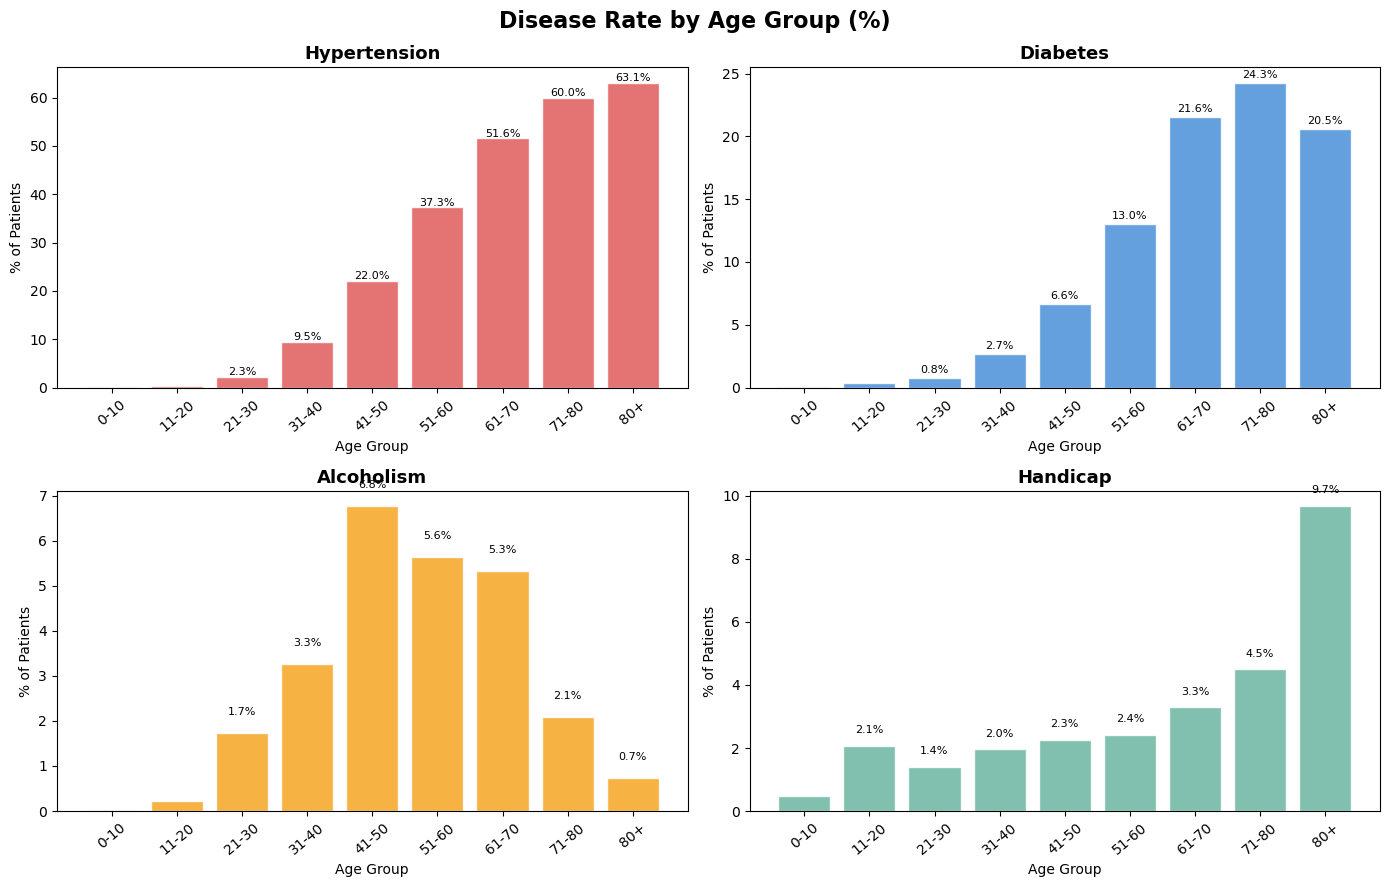

In [53]:
# visualizations
diseases = ["Hypertension", "Diabetes", "Alcoholism", "Handicap"]
colors   = ["#E05C5C", "#4A90D9", "#F5A623", "#6BB5A0"]
rate_df = (base_data.groupby("AgeBucket", observed=True)[diseases]
             .mean() * 100)
 
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle("Disease Rate by Age Group (%)", fontsize=16, fontweight="bold")
axes = axes.flatten()
 
for i, (disease, color) in enumerate(zip(diseases, colors)):
    vals = rate_df[disease].values
    axes[i].bar(rate_df.index.astype(str), vals,
                color=color, edgecolor="white", alpha=0.85)
    axes[i].set_title(disease, fontsize=13, fontweight="bold")
    axes[i].set_xlabel("Age Group")
    axes[i].set_ylabel("% of Patients")
    axes[i].tick_params(axis="x", rotation=40)
    for j, v in enumerate(vals):
        if v > 0.5:
            axes[i].text(j, v + 0.4, f"{v:.1f}%", ha="center", fontsize=8)
 
plt.tight_layout()
plt.show()

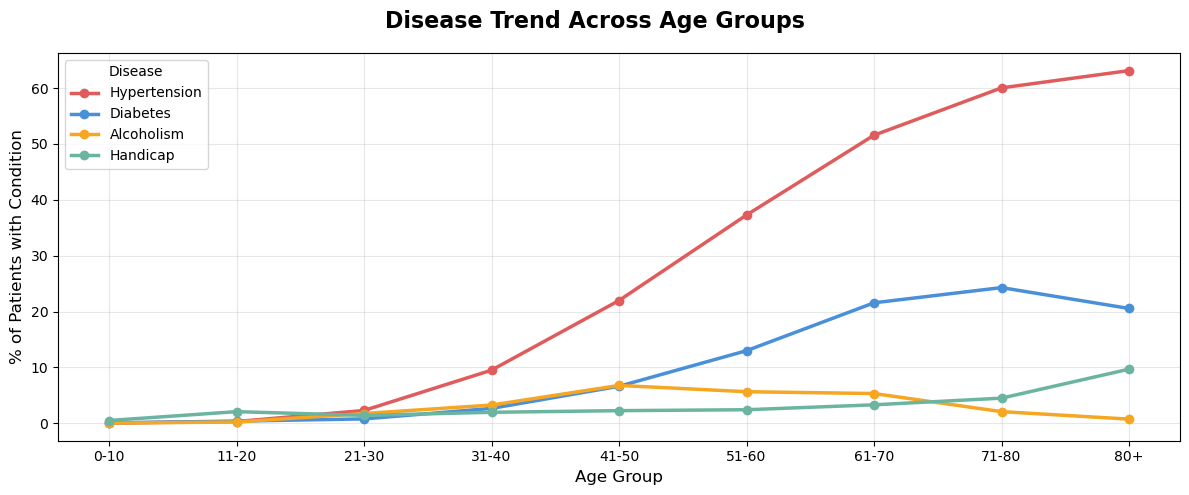

In [43]:
fig, ax = plt.subplots(figsize=(12, 5))
fig.suptitle("Disease Trend Across Age Groups", fontsize=16, fontweight="bold")
 
for disease, color in zip(diseases, colors):
    ax.plot(rate_df.index.astype(str), rate_df[disease].values,
            marker="o", linewidth=2.5, color=color, label=disease)
 
ax.set_xlabel("Age Group", fontsize=12)
ax.set_ylabel("% of Patients with Condition", fontsize=12)
ax.tick_params(axis="x")
ax.legend(title="Disease", fontsize=10)
ax.grid(alpha=0.3)
 
plt.tight_layout()
plt.show()
 

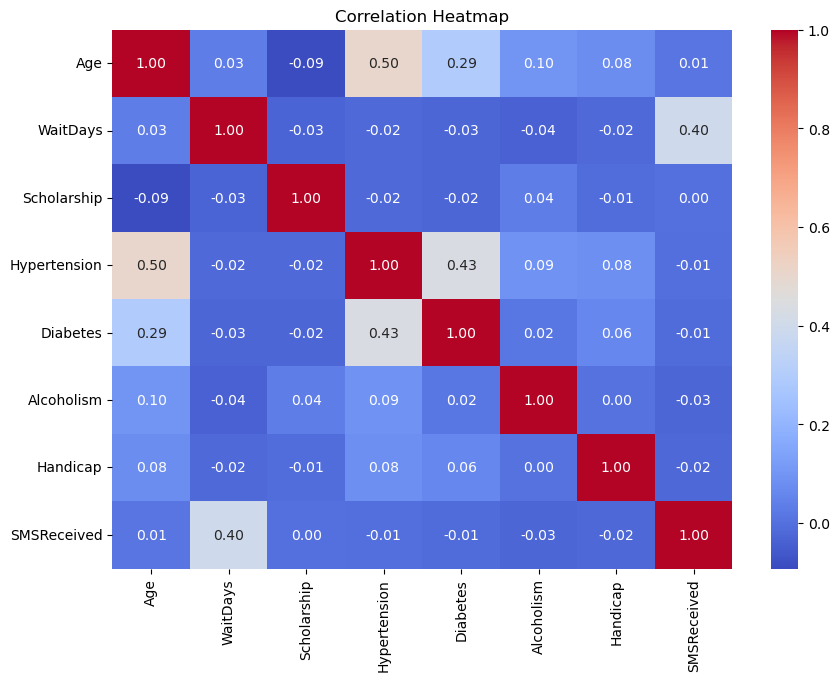

In [48]:

import seaborn as sns
import matplotlib.pyplot as plt
 
num_cols = ["Age", "WaitDays", "Scholarship", "Hypertension",
            "Diabetes", "Alcoholism", "Handicap", "SMSReceived" ]
 
corr = base_data[num_cols].corr()
 
plt.figure(figsize=(10, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

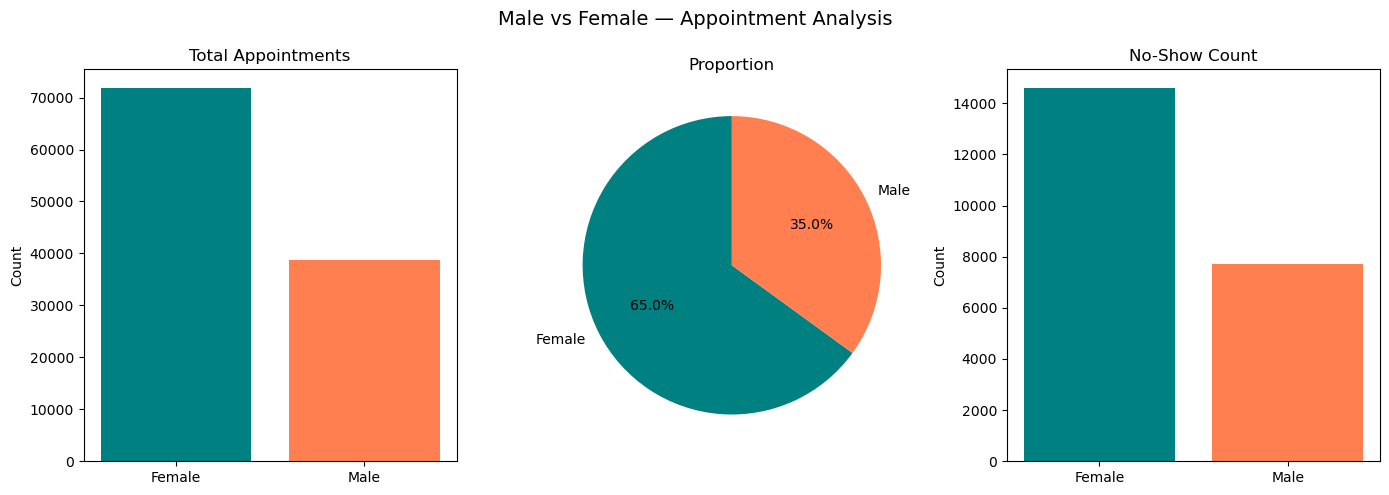

In [60]:

gender_counts = base_data["Gender"].value_counts()
noshow_gender = base_data[base_data["NoShow"] == "Yes"]["Gender"].value_counts()

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

axes[0].bar(["Female", "Male"], gender_counts.values, color=["teal", "coral"])
axes[0].set_title("Total Appointments")
axes[0].set_ylabel("Count")

axes[1].pie(gender_counts.values, labels=["Female", "Male"],
            colors=["teal", "coral"], autopct="%1.1f%%", startangle=90)
axes[1].set_title("Proportion")

axes[2].bar(["Female", "Male"], noshow_gender.values, color=["teal", "coral"])
axes[2].set_title("No-Show Count")
axes[2].set_ylabel("Count")

plt.suptitle("Male vs Female — Appointment Analysis", fontsize=14)
plt.tight_layout()
plt.show()

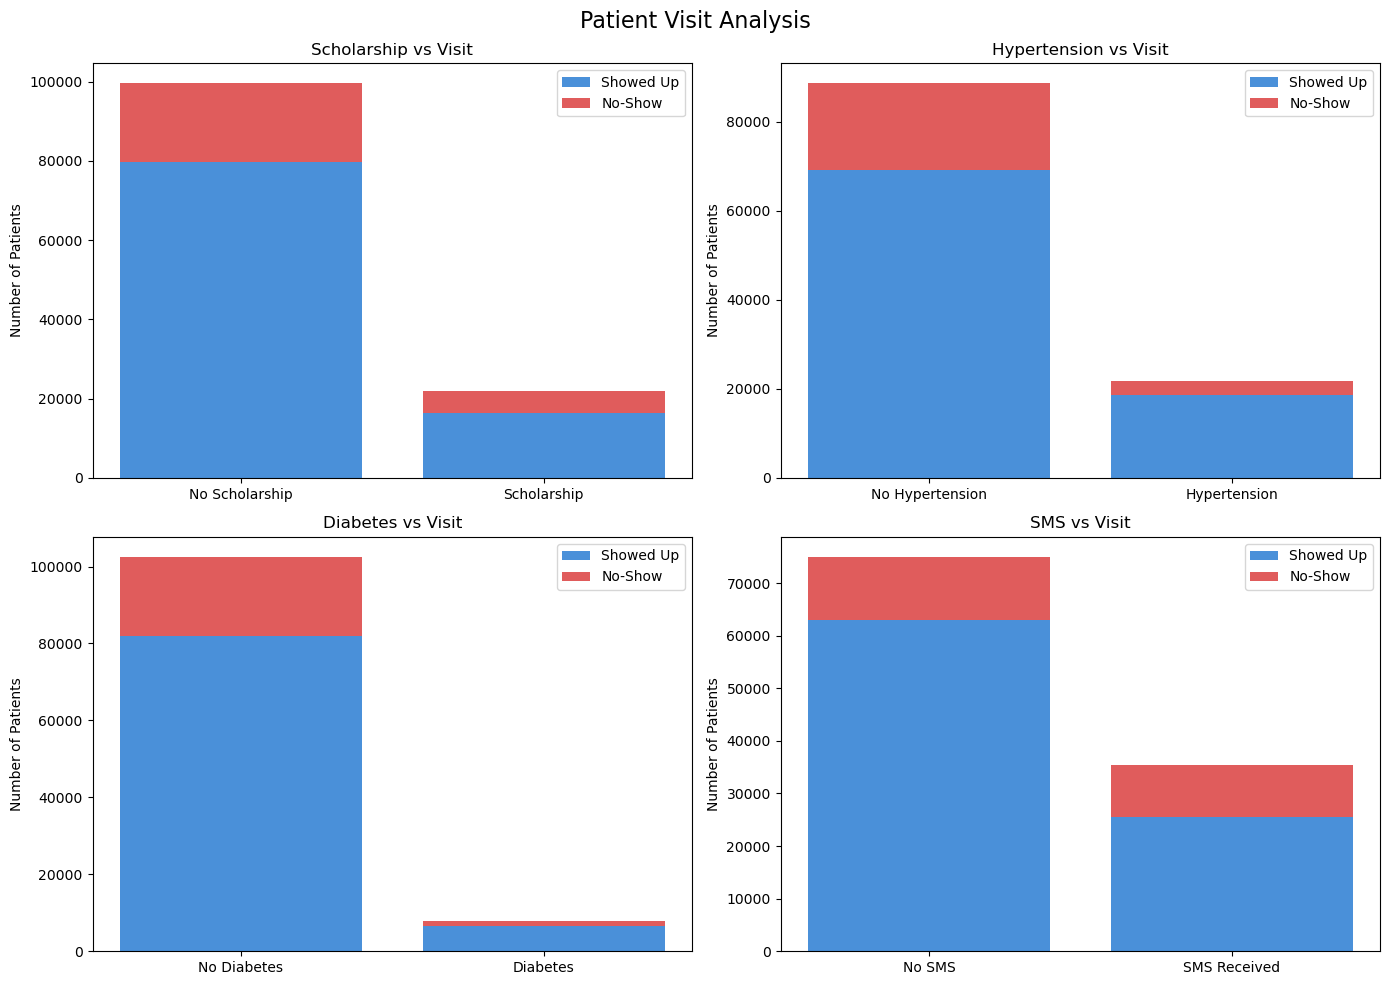

In [58]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Patient Visit Analysis", fontsize=16)
 
# scholarship
scholarship_counts = [99666, 21801]
showed = [round(99666 * 0.80), round(21801 * 0.75)]
noshow = [scholarship_counts[i] - showed[i] for i in range(2)]
 
axes[0][0].bar(["No Scholarship", "Scholarship"], showed, color="#4A90D9", label="Showed Up")
axes[0][0].bar(["No Scholarship", "Scholarship"], noshow, bottom=showed, color="#E05C5C", label="No-Show")
axes[0][0].set_title("Scholarship vs Visit")
axes[0][0].set_ylabel("Number of Patients")
axes[0][0].legend()

# hypertension
hyper_counts = [88726, 21801]
showed2 = [round(88726 * 0.78), round(21801 * 0.85)]
noshow2 = [hyper_counts[i] - showed2[i] for i in range(2)]
 
axes[0][1].bar(["No Hypertension", "Hypertension"], showed2, color="#4A90D9", label="Showed Up")
axes[0][1].bar(["No Hypertension", "Hypertension"], noshow2, bottom=showed2, color="#E05C5C", label="No-Show")
axes[0][1].set_title("Hypertension vs Visit")
axes[0][1].set_ylabel("Number of Patients")
axes[0][1].legend()
 
# diabetes
diabetes_counts = [102584, 7943]
showed3 = [round(102584 * 0.80), round(7943 * 0.83)]
noshow3 = [diabetes_counts[i] - showed3[i] for i in range(2)]
 
axes[1][0].bar(["No Diabetes", "Diabetes"], showed3, color="#4A90D9", label="Showed Up")
axes[1][0].bar(["No Diabetes", "Diabetes"], noshow3, bottom=showed3, color="#E05C5C", label="No-Show")
axes[1][0].set_title("Diabetes vs Visit")
axes[1][0].set_ylabel("Number of Patients")
axes[1][0].legend()
 
# SMS
sms_counts = [75045, 35482]
showed4 = [round(75045 * 0.84), round(35482 * 0.72)]
noshow4 = [sms_counts[i] - showed4[i] for i in range(2)]
 
axes[1][1].bar(["No SMS", "SMS Received"], showed4, color="#4A90D9", label="Showed Up")
axes[1][1].bar(["No SMS", "SMS Received"], noshow4, bottom=showed4, color="#E05C5C", label="No-Show")
axes[1][1].set_title("SMS vs Visit")
axes[1][1].set_ylabel("Number of Patients")
axes[1][1].legend()
 
plt.tight_layout()
plt.show()
 
